# Métodos de Aprendizado de Máquina para problemas de regressão

### **O que é um problema de regressão?**

Problemas de regressão são tarefas cujo objetivo é modelar e prever uma variável numérica contínua a partir de um conjunto de variáveis explicativas. Em outras palavras, busca-se aprender uma função que descreva a relação entre um conjunto de entradas (features ou preditores) e um valor de saída real. Essa função é geralmente determinada minimizando-se uma função de erro, como o erro quadrático médio, que mede o quão distante as previsões estão dos valores reais.

Problemas de regressão lidam com variáveis de saída contínuas. por exemplo, prever o preço de uma casa com base em características do imóvel. Diversos modelos podem ser utilizados para resolver problemas desse tipo. Entre os mais conhecidos estão a regressão linear, a regressão polinomial e técnicas de regularização, como ridge, lasso e elasticnet.

### **Regressão Linear e Polinomial**

A ideia seria aproximar uma curva de uma função objetivo com polinômios da forma $f(x) = a_0 + a_1x + ... + a_{n-1}x^{n-1}$ ou, de forma mais geral, prever um vetor $y$ utilizando funções de base polinomiais (tem que conter o bias por conta do conceito de intercepto).

A função de erro que queremos minimizar, nesse caso, é a de mínimos quadrados: $L(w) = \frac{1}{2} \sum_{n=1}^{N}(t_n - w^T\phi(x_n))²$ em que $w$ é o vetor de peso para os coeficientes (procuramos achar $w$ que minimize $L$), $t_n$ é uma coordenada do vetor target $t$, $x_n$ é um vetor de amostra da base de dados (ou seja, uma linha da base de dados) e $\phi$ é a função de ativação (com $\phi(x_0)$ sendo o vetor de 1's).

A solução ótima seria: $w = (X^TX)^{-1}X^Ty$. Contudo, $(X^TX)^{-1}$ pode nem sempre ter inversa.

### **Ridge, Lasso e Elastic Net**

Ridge, Lasso e Elastic Net são regularizadores da função de perda $L(w)$ que ajudam a controlar o sobreajuste do modelo aos dados.
- **Ridge**: $L(w) = \frac{1}{2} \sum_{n=1}^{N}(t_n - w^T\phi(x_n))² + \frac{1}{2}\lambda || w ||_2^2$ (solução: $w = (X^TX + \lambda I)^{-1}X^Ty$, $(X^TX + \lambda I)^{-1}$ existe quando $\lambda >0$)
- **Lasso**: $L(w) = \frac{1}{2} \sum_{n=1}^{N}(t_n - w^T\phi(x_n))² + \lambda || w ||_1$ (não tem solução analítica, mas podemos usar **sklearn.linear_model.Lasso**)
- **Elastic Net**: $L(w) = \frac{1}{2} \sum_{n=1}^{N}(t_n - w^T\phi(x_n))² + \frac{1}{2}\mu || w ||_2^2 + \lambda || w ||_1$ (não tem solução analítica, mas podemos usar **sklearn.linear_model.ElasticNet**)

### **Batchs e Stochastic Gradient Descent**

Em algoritmos de otimização baseados em gradiente, como o Stochastic Gradient Descent (SGD), o batch size determina quantos exemplos do conjunto de dados são usados para calcular o gradiente e atualizar os parâmetros do modelo em cada passo de treinamento.

O gradiente da perda indica a direção de maior crescimento da função, e o algoritmo de descida do gradiente atualiza os parâmetros na direção oposta.

Existem três formas principais de calcular esse gradiente, dependendo do tamanho do batch de dados utilizado:

- **Gradient Descent (batch completo)**
Nesse caso, o gradiente é calculado utilizando todas as amostras do conjunto de treinamento a cada atualização dos parâmetros. Portanto, o batch size é igual ao tamanho total do dataset. Esse método produz atualizações estáveis, pois utiliza toda a informação disponível, mas pode ser computacionalmente caro para conjuntos de dados grandes.

- **Stochastic Gradient Descent (SGD)**
No SGD clássico, o gradiente é calculado usando apenas uma única observação por vez. Assim, o batch size é igual a 1. Cada exemplo gera uma atualização dos parâmetros. Isso torna o treinamento muito mais rápido por iteração e permite começar a aprender imediatamente, mas as atualizações ficam com mais ruído, pois cada gradiente é baseado em pouca informação.

- **Mini-batch Gradient Descent**
Na prática, utiliza-se frequentemente uma abordagem intermediária chamada mini-batch, na qual o gradiente é calculado utilizando pequenos subconjuntos do dataset. Geralmente, o número de mini-batches é algum destes: 16, 32, 64 ou 128.

Lembrando que a atualização do SGD é $w_{t+1} = w_{t} - \alpha \nabla L(w_{t})$, em que $L$ é a função de perda.

In [ ]:
# Bibliotecas
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.datasets import load_diabetes
import numpy as np 
import matplotlib.pyplot as plt

### **Exemplo 1**

Vamos ver um exemplo de regressão polinomial (regressão linear é quando *degree* = 1) usando a pseudo-inversa de Moore-Penrose com a regularização Ridge (pois, como vimos a matriz sempre tem inversa quando $\lambda > 0$) com um conjunto de dados com apenas uma feature, ou seja, vamos prever o comportamento de uma curva. Se você quiser, pode retirar o fator de regularização, mas ao invés de *np.linalg.inv*, use *np.linalg.pinv*.

In [16]:
# Funções de perda
def rmse(x: np.array, y: np.array):
    return np.sqrt(np.mean((x - y)**2))

def sse(x: np.array, y: np.array):
    return 1/2 * np.sum((x-y)**2)

In [17]:
def polynomial_regression(X: np.array, y: np.array, degree: int=1, c: float=0.3) -> tuple:
    """Perform polynomial regression on input data.
    
    Parameters
    ----------
    X : np.array
        Input feature matrix (n_samples, n_features)
    y : np.array
        Target values (n_samples,1)
    degree : int
        Degree of the polynomial features
    
    Returns
    -------
    tuple
        (w, phi_matrix) where:
        - w : np.array
            Learned weights of the polynomial regression
        - phi_matrix : np.array
            Transformed feature matrix with polynomial features
    
    Notes
    -----
    Supports both univariate and multivariate input data. For multivariate data,
    creates polynomial features up to specified degree for each input feature.
    """

    rows = X.shape[0]
    cols = X.shape[1] * degree + 1
    phi_matrix = np.zeros((rows, cols))

    # One feature
    if X.shape[1] == 1:  
        for i in range(cols):
            phi_matrix[:, i] = X.flatten() ** i 
    
    # Multiple features    
    else:  
        for j in range(X.shape[1]):
            for i in range(degree):
                phi_matrix[:, i + j*degree] = X[:, j] ** (i+1)    

    # Regularization factor
    I = np.eye(phi_matrix.shape[1])
    I[0,0] = 0
    w = np.linalg.inv(phi_matrix.T @ phi_matrix + c*I) @ phi_matrix.T @ y
    
    return w, phi_matrix

In [18]:
def linear_regression_sklearn(X_train, y_train, X_test, y_test):
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    error = rmse(y_pred, y_test)
    
    return y_pred, error

In [19]:
# Dados com ruído gaussiano (livre para teste)
size = 50
np.random.seed(0)
x = np.linspace(0, 11, size)
noise = np.random.normal(0, 1, size)
y = 3 * x + 5 + noise

# Redimensionando para não termos problema
x = x.reshape(-1,1)
y = y.reshape(-1,1)

In [20]:
# Parâmetros da regressão e pesos da regressão 
degree = 1
c = 0.3
w, _ = polynomial_regression(x, y, degree, c)
n = w.shape[0]

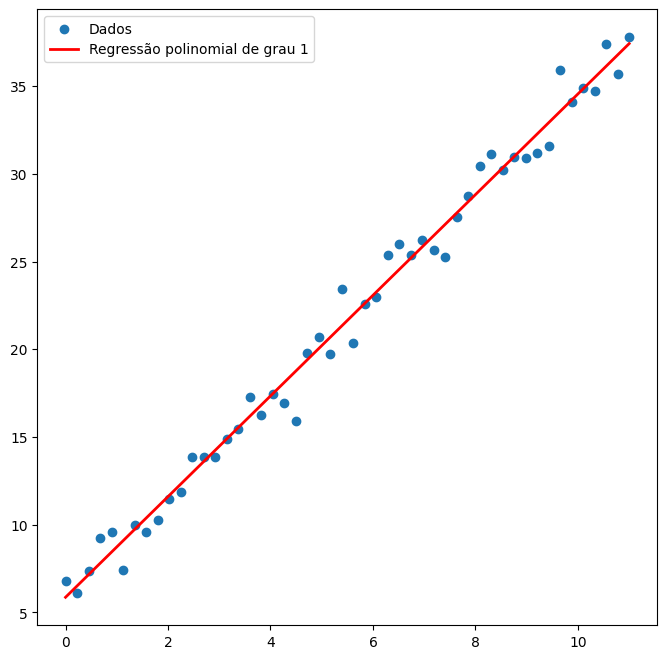

Vetor de pesos:
 [[5.855395  ]
 [2.87002987]]


In [21]:
# Gerar pontos para desenhar a curva mais suave (o que dita a suavidade é num)
x_plot = np.linspace(x.min(), x.max(), num=200).reshape(-1,1)

# Construir matriz polinomial para fazer uma curva suave da regressão
phi_plot = np.zeros((x_plot.shape[0], degree + 1))
for i in range(degree + 1):
    phi_plot[:, i] = x_plot.flatten() ** i

# Valores previstos para plot
y_pred = phi_plot @ w

# Plot
fig = plt.figure(figsize=(8, 8))
plt.scatter(x, y, label="Dados")
plt.plot(x_plot, y_pred, label=f"Regressão polinomial de grau {degree}", color = "red", linewidth=2)
plt.legend()
plt.show()

# Pesos de w
print("Vetor de pesos:\n", w)

### **Exemplo 2**

Agora, vamos ver um caso parecido com o exemplo 1, mas com várias features, ou seja, vamos prever um valor com base num vetor de features.

In [22]:
# Carregando dados
diabet_dataset = load_diabetes(return_X_y=False, as_frame=False)
X = diabet_dataset["data"]
y = diabet_dataset["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [23]:
# Parâmetros da regressão e pesos da regressão 
degree = 1
c = 0.1
w, _ = polynomial_regression(X_train, y_train, degree, c)

In [ ]:
# Construíndo a phi para o teste
rows = X_test.shape[0]
cols = X_test.shape[1] * degree
phi_test = np.zeros((rows, cols))

for j in range(X_test.shape[1]):
    for i in range(degree):
        phi_test[:, i + j*degree] = X_test[:, j] ** (i+1)
phi_test = np.hstack([np.ones((rows,1)), phi_test]) # Bias

# Montando a predição
y_pred = phi_test @ w

# Erro do modelo
error = rmse(y_test, y_pred)
print("Erro RMSE do modelo (sem sklearn):", error)

# Mesmo modelo, mas usando scikit-learn
y_pred, error = linear_regression_sklearn(X_train, y_train, X_test, y_test)
print("Erro RMSE do modelo (com sklearn):", error)

Erro do modelo (sem sklearn): 105.12615767968649
Erro do modelo (com sklearn): 57.166324275051515


In [ ]:
# Aqui estão algumas funções usando ridge, lasso e elasticnet do sklearn


def ridge_regression(X: np.array, y: np.array, penalty: float) -> tuple:
    
    model = Ridge(alpha=penalty, fit_intercept=True)
    model.fit(X, y)
    y_pred = model.predict(X)
    rmse_error = rmse(y, y_pred)

    return y_pred, rmse_error


def best_lambda(X_train, X_pred, y_train, y_pred, penalties):
    
    rmse_hist_training = []
    rmse_hist_pred = []
    phi_matrix_pred = X_pred.copy()
    phi_matrix_pred = np.hstack([np.ones((phi_matrix_pred.shape[0], 1)), phi_matrix_pred])
    for penalty in penalties:
        w_train, rmse_train = ridge_regression(X_train, y_train, penalty)
        rmse_hist_training.append(rmse_train)
        rmse_pred = rmse(y_pred, phi_matrix_pred @ w_train)
        rmse_hist_pred.append(rmse_pred)
    best_lambda = penalties[np.argmin(rmse_hist_pred)]

    return best_lambda, rmse_hist_training, rmse_hist_pred


def lasso_regression(X, X_pred, y, y_pred, alpha):
    
    lasso_regression = Lasso(alpha=alpha).fit(X, y)
    y_pred = lasso_regression.predict(X_pred)
    rmse_lasso = float(np.sqrt(np.mean((y_pred - y_pred)**2)))
    
    return y_pred, rmse_lasso


def lasso_best_alpha(X, X_pred, y, y_pred, alpha_values):
    
    rmse_hist_x = []
    rmse_hist_pred = []
    for alpha_value in alpha_values:
        _, rmse_x = lasso_regression(X, X, y, y, alpha_value)  # Aprendo os parâmetros (w) com o de treino
        _, rmse_pred = lasso_regression(X, X_pred, y, y_pred, alpha_value)  # Regulo o hiperparâmetro (alpha) com o de validação
        rmse_hist_x.append(rmse_x)
        rmse_hist_pred.append(rmse_pred)
    best_alpha = alpha_values[np.argmin(rmse_hist_pred)]
    
    return best_alpha


def ElasticNet_Regression(X_training, X_testing, y_training, y_testing, alpha_value, lambda_value):

    ELRegression = ElasticNet(alpha=alpha_value, l1_ratio=lambda_value).fit(X_training, y_training)
    y_pred = ELRegression.predict(X_testing)
    rmse_EL = float(np.sqrt(np.mean((y_testing - y_pred)**2)))
    
    return y_pred, rmse_EL

### **Exemplo 3**

Agora, vamos ver a regressão usando SGD.

In [25]:
def regression_sgd(phi_matrix: np.array, y: np.array, lr: float=0.001, epochs: int=100, batch_size: int=32, c: float=0.3) -> tuple:
    """
    Implements a Linear Regression model using Stochastic Gradient Descent
    
    Parameters
    ----------
    X : array
        A 2-dimensional array with samples in the rows and features in the columns
    y : array
        An array with the same number of  as samples in X, the values to predict
    lr : float
        Learning rate
    epochs : int
        number of epochs to use for the gradient descent
    
    Returns
    -------
    w : array
        Learnt parameters
    sse_history : list
        A list that contains the error of the model in every iteration
        
    Notes
    -----
    This function uses the gradient of the sum of squares function (Equations 3.12, and 3.23 in the Bishop book)
    """

    # Initialize weights with random values from a normal distribution (small variation)
    w_0 = np.random.normal(0, 0.01, phi_matrix.shape[1])
    w = w_0.copy()

    # Store SSE
    sse_history = []

    # Perform Stochastic Gradient Descent (SGD)
    for _ in range(epochs):
        
        # Shuffle the data in each epoch
        indices = np.random.permutation(phi_matrix.shape[0])
        
        for i in indices:
            
            # Get current data point
            phi_xi = phi_matrix[i]

            # Compute error and the sse for the current data point
            sse_error = sse(y[i], np.dot(w, phi_xi))
            sse_history.append(sse_error)  # Store SSE

            # Calculate the gradient
            gradient = -(y[i] - np.dot(w, phi_xi)) * phi_xi

            # Update weights
            w = w - lr * gradient

    return w, sse_history

Erro do modelo (com SGD): 72.3419797080074


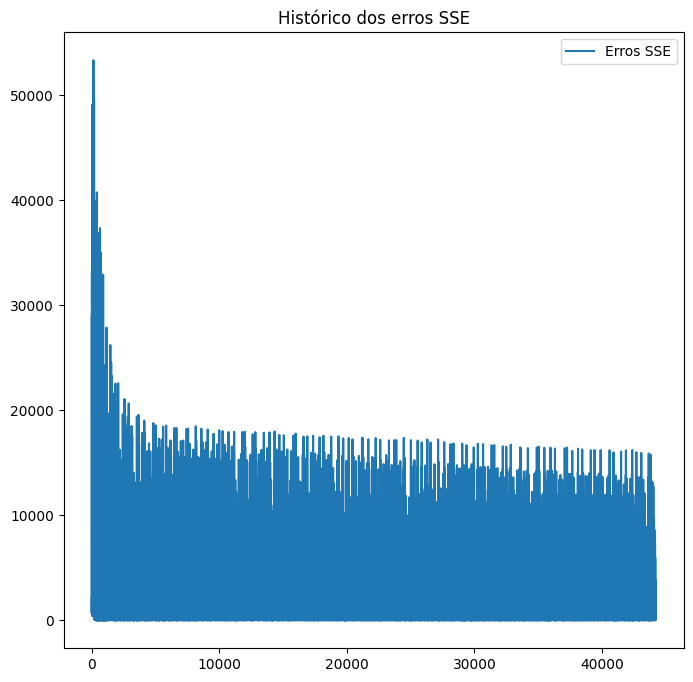

In [ ]:
# Montando um phi_matrix linear (mas pode ser qualquer uma) e predizendo o vetor de pesos
phi_matrix = X.copy()
phi_matrix = np.hstack([np.ones((phi_matrix.shape[0], 1)), phi_matrix])
epochs = 100
w, sse = regression_sgd(phi_matrix, y, epochs=epochs)

# Montando a predição
y_pred = phi_test @ w

# Erro do modelo
error = rmse(y_test, y_pred)
print("Erro RMSE do modelo (com SGD):", error)

# Plotando o histórico de erros SSE
fig = plt.figure(figsize=(8, 8))
plt.plot(sse, label="Erros SSE")
plt.title("Histórico dos erros SSE")
plt.legend()
plt.show()